# Clase 6: Fundamentos de Numpy


## Objetivos

- Entender por qué y cuándo usar numpy en vez de solo pandas o listas de Python
- Dominar la creación, manipulación y operaciones rápidas sobre arrays
- Realizar transformaciones y análisis prácticos (números e imágenes)


---



## ¿Por qué Numpy? 🤔

1. Velocidad y eficiencia: numpy usa **arrays de bajo nivel** (C/C++), mucho más rápidos que listas de Python para cálculos grandes.
2. Uso en **ciencia de datos y ML**: muchas librerías (scikit-learn, tensorflow, pytorch) usan numpy internamente.
3. Manipulación de datos **multidimensionales**: arrays n-dim (matrices, imágenes, señales...)
4. Diferencia clave: pandas es para tablas y series con etiquetas, numpy es para **cálculo numérico intensivo** y manejo eficiente de arrays.



In [1]:
import numpy as np
import pandas as pd
# Multiplicar por dos 1 millón de números
x_np = np.arange(1_000_000)
x_list = list(range(1_000_000))

In [22]:
%timeit x_np * 2  # numpy

900 µs ± 160 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [23]:
%timeit [i*2 for i in x_list]  # puro python

65.8 ms ± 9.78 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


---
## Creación de arrays y operaciones básicas

In [4]:
np.zeros((3,3))  # Matriz de 3X3 que solo contiene ceros

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [5]:
np.ones((2,4)) # Matriz de 2 filas x 4 columnas que solo contiene unos

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [6]:
np.arange(0, 11, 2) # Vector de números del 0 al 10, con saltos de 2

array([ 0,  2,  4,  6,  8, 10])

In [28]:
np.linspace(0, 1, 20) # Vector que contiene 5 valores entre el valor de inicio 0 y el valor de fin 1

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])

In [41]:
# Construir un arreglo de numpy desde una lista
arr = np.array([[[1, 2, 3.0],[4, 5, 6]],[[1, 2, 3],[4, 5, 6]]])
arr

array([[[1., 2., 3.],
        [4., 5., 6.]],

       [[1., 2., 3.],
        [4., 5., 6.]]])

In [46]:
# Construir un arreglo de numpy desde una lista
arr = np.array([[1,2,3,4,5],[1,2,3,4,5]])
arr

array([[1, 2, 3, 4, 5],
       [1, 2, 3, 4, 5]])

In [47]:
arr.shape # Forma del arreglo

(2, 5)

In [43]:
arr.size # Tamaño del arreglo (Cantidad de elementos que contiene)

12

In [44]:
arr.dtype # Tipo de datos del arreglo

dtype('float64')

---
## Indexación, slicing y broadcasting

In [95]:
A = np.arange(20).reshape(4,5)
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [70]:
A.shape

(4, 5)

In [69]:
print(f"Elemento fila 3, col 2: {A[1, 0]}\n")   # Elemento fila 3, col 2
print(f"Segunda columna: {A[:, 1]}\n")   # Segunda columna
print(f"tercera fila: {A[2, :]}\n")   # tercera fila
print(f"Filas 1 y 2: \n{A[1:3, :]}\n")   # Filas 1 y 2
print(f"4 ultimas columnas de la ultima fila : \n{A[3, 1:5]}\n")   # Filas 1 y 2

Elemento fila 3, col 2: 5

Segunda columna: [ 1  6 11 16]

tercera fila: [10 11 12 13 14]

Filas 1 y 2: 
[[ 5  6  7  8  9]
 [10 11 12 13 14]]

4 ultimas columnas de la ultima fila : 
[16 17 18 19]



In [73]:
A[0,:]

array([0, 1, 2, 3, 4])

In [74]:
A[2,:]

array([10, 11, 12, 13, 14])

In [82]:
np.concatenate(([A[0,:]], [A[2,:]]), axis=0)

array([[ 0,  1,  2,  3,  4],
       [10, 11, 12, 13, 14]])

In [96]:
A

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

In [97]:
A[0,0] = 400

In [98]:
A

array([[400,   1,   2,   3,   4],
       [  5,   6,   7,   8,   9],
       [ 10,  11,  12,  13,  14],
       [ 15,  16,  17,  18,  19]])

In [94]:
print(A + 10) #Suma 10 a cada valor del arreglo
print()
print(A * 2) #Multiplica por 2 cada valor del arreglo
print()
A[ A % 2 ==  0] = 0   # Poner ceros donde hay impares
print(A)

[[10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]
 [25 26 27 28 29]]

[[ 0  2  4  6  8]
 [10 12 14 16 18]
 [20 22 24 26 28]
 [30 32 34 36 38]]

[[ 0  1  0  3  0]
 [ 5  0  7  0  9]
 [ 0 11  0 13  0]
 [15  0 17  0 19]]


---
## Operaciones rápidas y filtrado

In [101]:
A

array([[400,   1,   2,   3,   4],
       [  5,   6,   7,   8,   9],
       [ 10,  11,  12,  13,  14],
       [ 15,  16,  17,  18,  19]])

In [119]:
np.sum(A, axis=1)

array([410,  35,  60,  85])

In [102]:
print(f"Promedio de los valores del arreglo: {np.mean(A)}")
print()
print(f"Mediana de los valores del arreglo: {np.median(A)}")
print()
print(f"Desviación estandar de los valores del arreglo: {np.std(A)}")
print()
print(f"Sumatoria de los valores del arreglo por columna: {np.sum(A, axis=0)}")
print()
print(f"Maximo entre los valores del arreglo por fila: {np.max(A, axis=1)}")

Promedio de los valores del arreglo: 29.5

Mediana de los valores del arreglo: 10.5

Desviación estandar de los valores del arreglo: 85.1660143484477

Sumatoria de los valores del arreglo por columna: [430  34  38  42  46]

Maximo entre los valores del arreglo por fila: [400   9  14  19]


In [124]:
# Filtrado booleano
A[A < 15]  # Todos los menores de 15

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

---
## Lectura y manipulación de imágenes con numpy

In [125]:
from PIL import Image  ## Uso de la libreria Pillow
img = Image.open('Gatillo.jpg').convert('RGB')
img_array = np.array(img)
img_array

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  7,   7,   7],
        [  7,   7,   7],
        [  7,   7,   7]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  7,   7,   7],
        [  7,   7,   7],
        [  7,   7,   7]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [  6,   6,   6],
        [  6,   6,   6],
        [  6,   6,   6]],

       ...,

       [[163, 163, 161],
        [163, 163, 161],
        [163, 163, 161],
        ...,
        [ 27,  25,  26],
        [ 27,  25,  26],
        [ 27,  25,  26]],

       [[163, 163, 161],
        [163, 163, 161],
        [163, 163, 161],
        ...,
        [ 27,  25,  26],
        [ 27,  25,  26],
        [ 27,  25,  26]],

       [[163, 163, 161],
        [163, 163, 161],
        [163, 163, 161],
        ...,
        [ 27,  25,  26],
        [ 27,  25,  26],
        [ 27,  25,  26]]

In [127]:
img_array.shape  # (alto, ancho, canales)

(3000, 4000, 3)

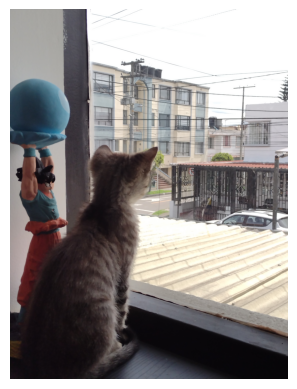

In [126]:
import matplotlib.pyplot as plt
plt.imshow(np.rot90(img_array, 3)) # Rotar la imagen 270 grados a la izquierda y Mostrarla
plt.axis('off')
plt.show()

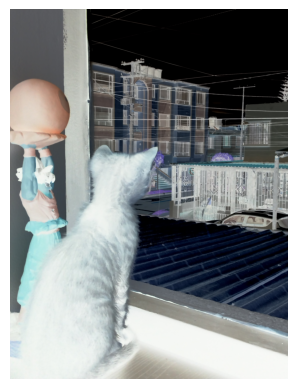

In [128]:
negativo = 255 - img_array
plt.imshow(np.rot90(negativo, 3))
plt.axis('off')
plt.show()

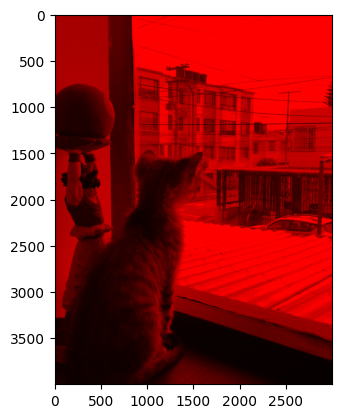

In [144]:
import numpy as np
import matplotlib.pyplot as plt

red_image = np.zeros_like(img_array)
green_image = np.zeros_like(img_array)
blue_image = np.zeros_like(img_array)

# Solo dejamos el canal azul
red_image[:, :, 0] = img_array[:, :, 0]

plt.imshow(np.rot90(red_image,3))

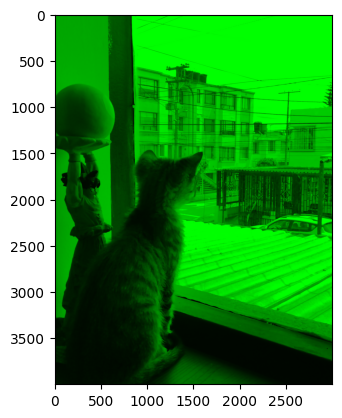

In [143]:

plt.imshow(np.rot90(red_image,3))
green_image[:, :, 1] = img_array[:, :, 1]

plt.imshow(np.rot90(green_image,3))


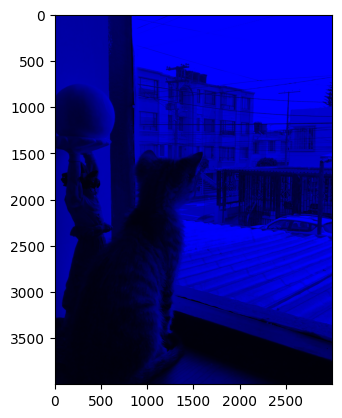

In [142]:
blue_image[:, :, 2] = img_array[:, :, 2]

plt.imshow(np.rot90(blue_image,3))


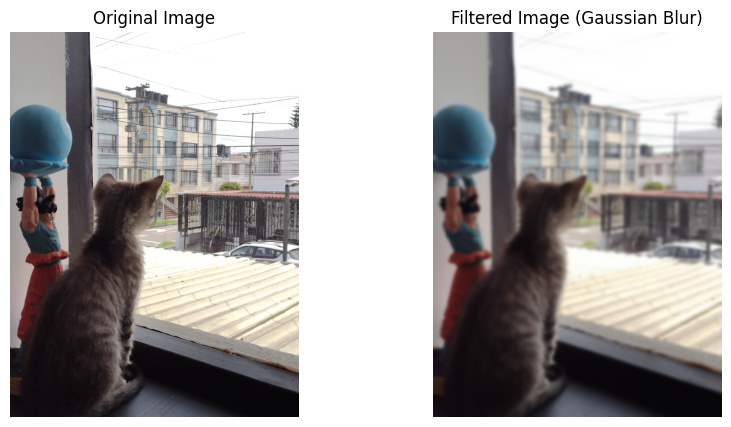

In [129]:
from scipy.ndimage import gaussian_filter


image = np.array(Image.open("Gatillo.jpg")) / 255.0  # Normalize to [0, 1]

# Define the standard deviation (sigma) for the Gaussian filter
sigma = 15.0  # Adjust this value for more or less blurring

# Apply Gaussian filter to each channel (R, G, B) separately
filtered_image = np.zeros_like(img_array)  # Initialize an array for the filtered image
for channel in range(3):  # Loop over the 3 color channels
    filtered_image[:, :, channel] = gaussian_filter(img_array[:, :, channel], sigma=sigma)

# Display the original and filtered images
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(np.rot90(img_array,3))
plt.axis("off")

# Filtered image
plt.subplot(1, 2, 2)
plt.title("Filtered Image (Gaussian Blur)")
plt.imshow(np.rot90(filtered_image,3))
plt.axis("off")

plt.show()


---
## Ejercicio en clase

1. Crea un arreglo 5x3 de números aleatorios entre 0 y 100
2. ¿Cuál es la suma total de los valores del arreglo?
3. ¿Cúal es el promedio de cada columna del arreglo?
4. Crea una matriz 10x10 de enteros aleatorios (0-9).
5. Pon en -1 todos los valores > 5
6. Abre una imagen, muestra shape, min, max y promedio de cada canal